<div align="left">

<h2><b>Producing Figures</b></h2>

</div>

#### <u><strong> Setup.</strong></u>

In [ ]:
# Needed packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from google.colab import drive
import os
from tensorflow import keras
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import zipfile
import tensorflow as tf
import io
from PIL import Image
import math
from shapely.geometry import Point

# Mount drive and set current directory
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/London School of Economics/Deep Learning/DeepLearningProject/Code')

# Directories
RESULTS_DIR = "../Results"
PHOTO_DIR  = "../Input/GoogleStreetViewImagesNew.zip"
PHOTO_DIR_Philly  = "../Input/GoogleStreetViewImagesPhilly.zip"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
##############################
# I. Data loading (Modified) #
##############################
# Sources:
# Assignment I dataloading fn &
# https://medium.com/@kumudtraveldiaries/step-by-step-preprocessing-guide-for-images-in-both-cnn-and-dense-layer-pipelines-1994c3ad3e87
def dataloading(csv_path="../Output/images_bra.csv",
                zip_path=PHOTO_DIR,
                img_size=128,
                batch_size=32,
                preprocess_fn=None,
                variable="income_group",
                Philly=False):

    # 1. Load CSV
    df = pd.read_csv(csv_path)
    df = df.dropna(subset=[variable]).reset_index(drop=True)

    # 2. Build group IDs
    df["loc_id"] = df["file_path"].apply(
        lambda f: os.path.basename(f).split("_h")[0]
    )

    # 3. Train / Val / Test split
    if Philly:
        train_df = None
        val_df = None
        test_df = df.copy()
    else:
        locs = df["loc_id"].unique()
        np.random.seed(50)
        np.random.shuffle(locs)

        n_test = int(len(locs) * 0.15)
        n_val = int(len(locs) * 0.15)

        test_locs = locs[:n_test]
        val_locs = locs[n_test:n_test + n_val]
        train_locs = locs[n_test + n_val:]

        train_df = df[df["loc_id"].isin(train_locs)]
        val_df = df[df["loc_id"].isin(val_locs)]
        test_df = df[df["loc_id"].isin(test_locs)]

    # 4. Open zip once
    zip_ref = zipfile.ZipFile(zip_path, "r")

    # 5. Image loading function
    def load_image_from_zip(path, label):
        def _read(path_tensor):
            p = path_tensor.numpy().decode("utf-8")
            img_data = zip_ref.read(p)

            img = tf.image.decode_jpeg(img_data, channels=3)
            img = tf.image.resize(img, [img_size, img_size])
            img = tf.cast(img, tf.float32)

            if preprocess_fn:
                img = preprocess_fn(img)
            else:
                img = img / 255.0

            return img

        img = tf.py_function(_read, [path], tf.float32)
        img.set_shape([img_size, img_size, 3])

        return img, label

    # 6. Dataset builder
    def make_dataset(split_df, is_train=False):
        labels = split_df[variable].values.astype(np.int64)
        paths = split_df["file_path"].values

        ds = tf.data.Dataset.from_tensor_slices((paths, labels))

        if is_train:
            ds = ds.shuffle(len(paths))

        ds = ds.map(load_image_from_zip, num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

        return ds

    if Philly:
        print(f"test: {len(test_df)} images")

        train_ds = None
        val_ds = None
        test_ds = make_dataset(test_df)

    else:
        print(f"train: {len(train_df)} images")
        print(f"val: {len(val_df)} images")
        print(f"test: {len(test_df)} images")

        train_ds = make_dataset(train_df, is_train=True)
        val_ds = make_dataset(val_df)
        test_ds = make_dataset(test_df)

    return train_ds, val_ds, test_ds, test_df

###############################
# II. Model + aggregation call #
###############################

def load_model_and_aggregate(model_path, train_ds, test_ds, test_df):
    # Load model
    model = keras.models.load_model(model_path, compile=False)

    total_steps = 30 * 15338

    cosine_lr = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=1e-5,
        decay_steps=total_steps,
        alpha=1e-7,
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=cosine_lr),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"],
    )

    # Image-level sanity check
    loss, acc = model.evaluate(test_ds, verbose=1)
    print(f"\nImage-level sanity check: Loss: {loss:.4f} | Accuracy: {acc:.4f}")

    # Predict once
    all_probs = []
    all_labels = []

    for x_batch, y_batch in test_ds:
        probs = model.predict(x_batch, verbose=0)
        all_probs.append(probs)
        all_labels.append(y_batch.numpy())

    probs = np.concatenate(all_probs)
    true = np.concatenate(all_labels)

    # Image-level results
    results_img = test_df.copy().reset_index(drop=True)
    results_img["actual"] = true

    for c in range(probs.shape[1]):
        results_img[f"prob_{c}"] = probs[:, c]

    prob_cols = [f"prob_{c}" for c in range(probs.shape[1])]

    # Median aggregation by loc_id
    results = (
        results_img
        .groupby("loc_id")
        .agg(
            actual=("actual", "first"),
            GEOID=("GEOID", "first"),
            file_path=("file_path", "first"),
            **{col: (col, "median") for col in prob_cols}
        )
        .reset_index()
    )

    results["predicted"] = results[prob_cols].values.argmax(axis=1)

    # Aggregated accuracy
    agg_acc = (results["actual"] == results["predicted"]).mean()
    print(f"Median aggregation accuracy: {agg_acc:.4f}")

    return model, results

#### <u><strong> (i) Figure 1</strong></u> : Training and Validation Loss and Accuracy (top 1) for all models.

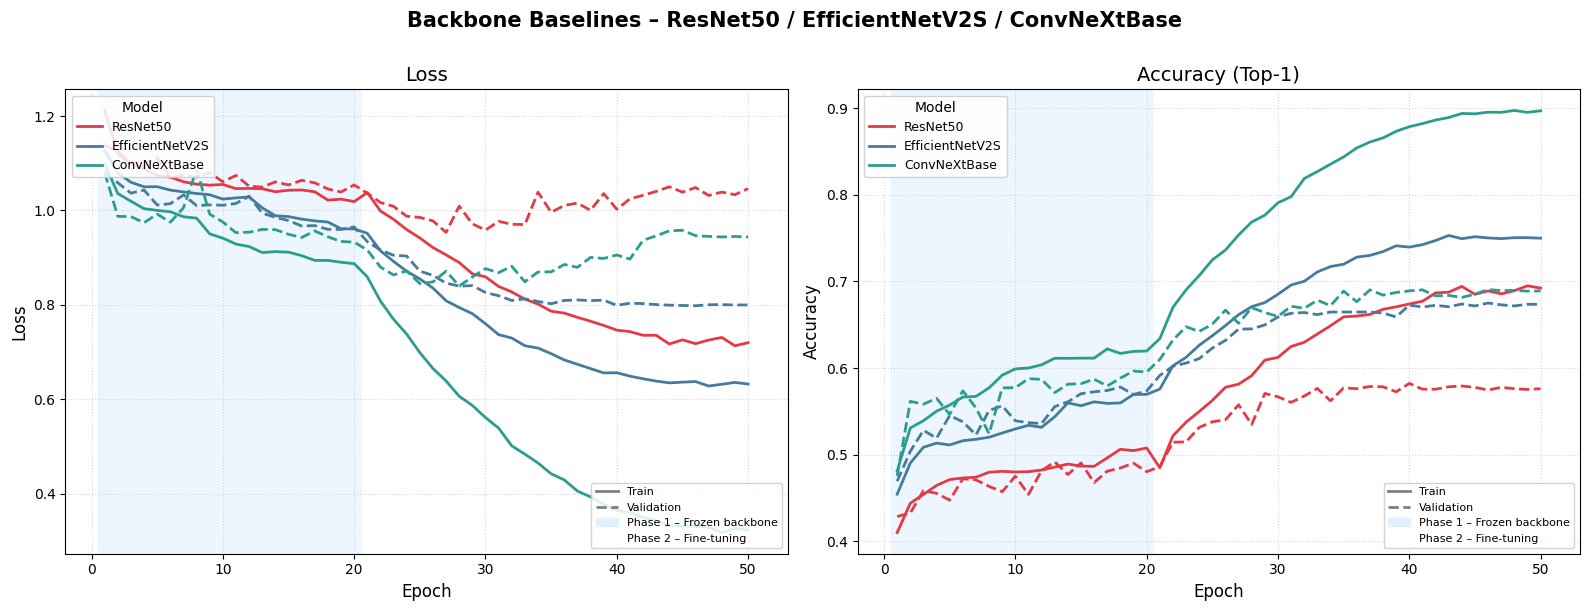

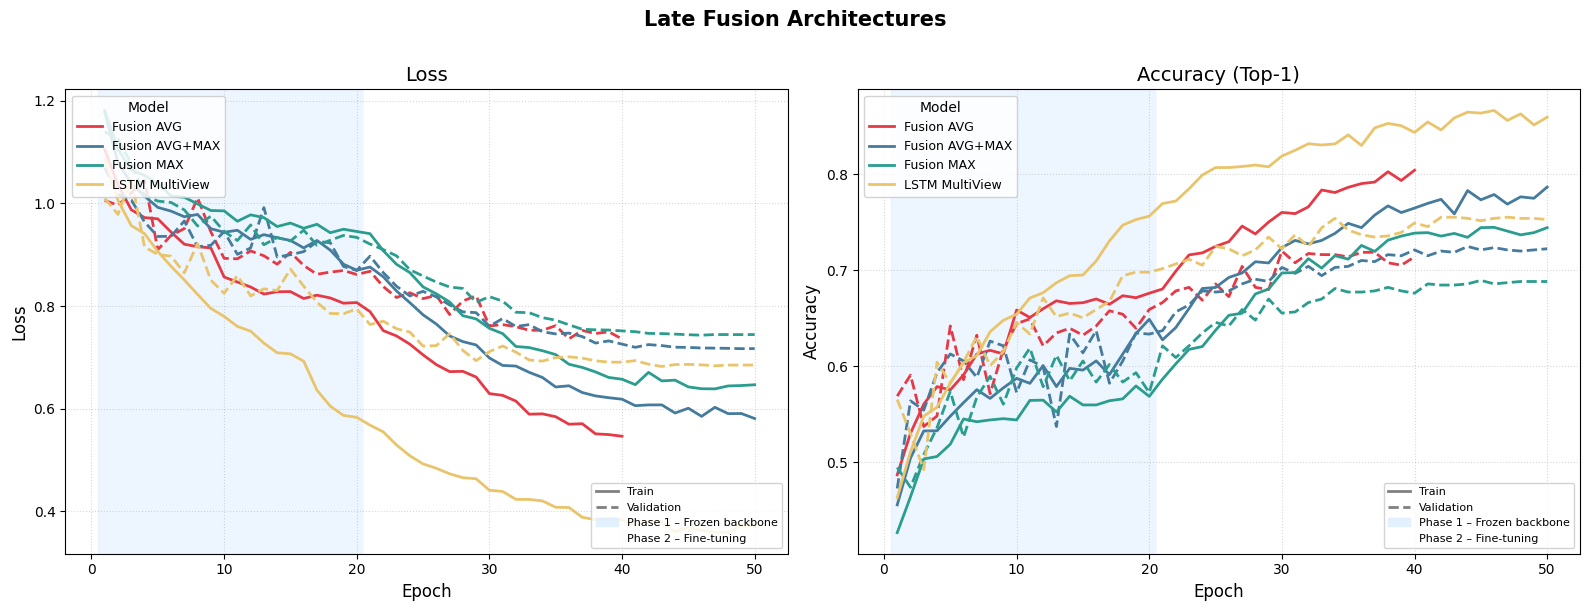

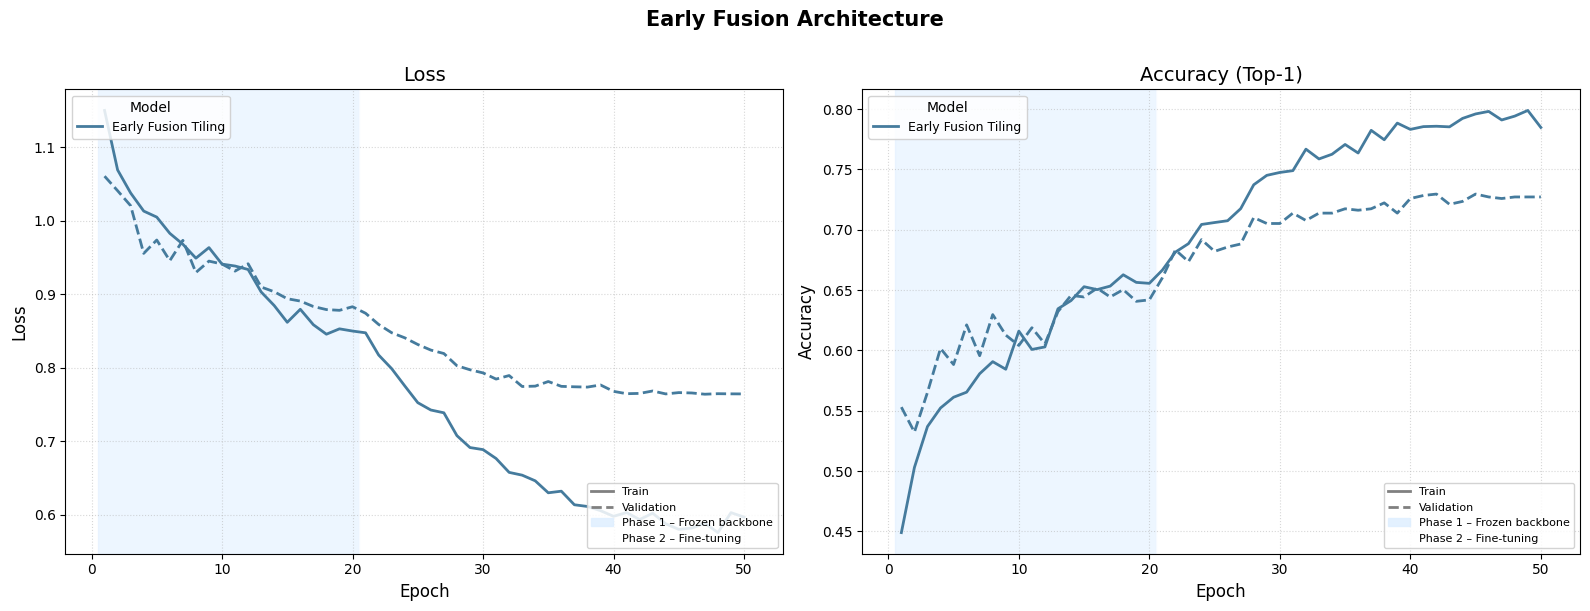

In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


DIRECTORY = "/content"

LABEL_MAP = {
    "ResNet50_IncomeGroup.csv": "ResNet50",
    "EfficientNetV2S_IncomeGroup.csv": "EfficientNetV2S",
    "ConvNext_income_group.csv": "ConvNeXtBase",
    "Efficientnetv2s_fusion_avg_income_group.csv": "Fusion AVG",
    "Efficientnetv2s_fusion_avg_max_income_group.csv": "Fusion AVG+MAX",
    "Efficientnetv2s_fusion_max_income_group.csv": "Fusion MAX",
    "Efficientnetv2s_lstm_multiview_income_group.csv":"LSTM MultiView",
    "Early_fusion_tiling_income_group.csv": "Early Fusion Tiling",
}

GROUP1 = [
    "ResNet50_IncomeGroup.csv",
    "EfficientNetV2S_IncomeGroup.csv",
    "ConvNext_income_group.csv",
]

GROUP2 = [
    "Efficientnetv2s_fusion_avg_income_group.csv",
    "Efficientnetv2s_fusion_avg_max_income_group.csv",
    "Efficientnetv2s_fusion_max_income_group.csv",
    "Efficientnetv2s_lstm_multiview_income_group.csv",
]

GROUP3 = [
    "Early_fusion_tiling_income_group.csv",
]

phase_colors = {1: "#DDEEFF", 2: "#FFFFFF"}
phase_labels  = {1: "Phase 1 – Frozen backbone", 2: "Phase 2 – Fine-tuning"}

PALETTE = [
    "#E63946", "#457B9D", "#2A9D8F",
    "#E9C46A", "#F4A261", "#6A4C93",
    "#1982C4", "#8AC926", "#FF595E",
]

def full_path(fname):
    return os.path.join(DIRECTORY, fname)

def load(fname):
    df = pd.read_csv(full_path(fname))
    rows, offset = [], 0
    for phase, grp in df.groupby("phase", sort=True):
        grp = grp.copy()
        grp["global_epoch"] = grp["epoch"] + offset
        rows.append(grp)
        offset += len(grp)
    return pd.concat(rows).reset_index(drop=True)

def get_phase_bounds(fname):
    df = pd.read_csv(full_path(fname))
    bounds, offset = {}, 0
    for phase, grp in df.groupby("phase", sort=True):
        bounds[phase] = (offset + 1, offset + len(grp))
        offset += len(grp)
    return bounds

def plot_group(fnames, title, palette_offset=0):
    # Filter to files that actually exist
    available = [f for f in fnames if os.path.exists(full_path(f))]
    missing   = [f for f in fnames if f not in available]
    if missing:
        print(f"[{title}] Missing files: {missing}")
    if not available:
        print(f"  → Skipping '{title}': no files found.")
        return

    fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(16, 6))

    bounds = get_phase_bounds(available[0])
    for ax in (ax_loss, ax_acc):
        for phase, (x0, x1) in bounds.items():
            ax.axvspan(x0 - 0.5, x1 + 0.5,
                       color=phase_colors[phase], alpha=0.5, zorder=0)

    for idx, fname in enumerate(available):
        df_plot = load(fname)
        color = PALETTE[(palette_offset + idx) % len(PALETTE)]
        label = LABEL_MAP.get(fname, fname.replace(".csv", ""))

        ax_loss.plot(df_plot["global_epoch"], df_plot["loss"],
                     color=color, linewidth=2, label=label)
        ax_loss.plot(df_plot["global_epoch"], df_plot["val_loss"],
                     color=color, linewidth=2, linestyle="--")

        ax_acc.plot(df_plot["global_epoch"], df_plot["accuracy"],
                    color=color, linewidth=2, label=label)
        ax_acc.plot(df_plot["global_epoch"], df_plot["val_accuracy"],
                    color=color, linewidth=2, linestyle="--")

    solid_line  = plt.Line2D([0], [0], color="grey", lw=2, ls="-",  label="Train")
    dashed_line = plt.Line2D([0], [0], color="grey", lw=2, ls="--", label="Validation")
    p1_patch = mpatches.Patch(color=phase_colors[1], alpha=0.8, label=phase_labels[1])
    p2_patch = mpatches.Patch(color=phase_colors[2], alpha=0.8, label=phase_labels[2])

    ax_loss.set_title("Loss", fontsize=14)
    ax_loss.set_ylabel("Loss", fontsize=12)
    ax_loss.set_xlabel("Epoch", fontsize=12)

    ax_acc.set_title("Accuracy (Top-1)", fontsize=14)
    ax_acc.set_ylabel("Accuracy", fontsize=12)
    ax_acc.set_xlabel("Epoch", fontsize=12)

    for ax in (ax_loss, ax_acc):
        mh, ml = ax.get_legend_handles_labels()
        leg1 = ax.legend(mh, ml, loc="upper left", fontsize=9,
                         title="Model", title_fontsize=10, framealpha=0.85)
        ax.add_artist(leg1)
        ax.legend(handles=[solid_line, dashed_line, p1_patch, p2_patch],
                  loc="lower right", fontsize=8, framealpha=0.85)
        ax.grid(True, linestyle=":", alpha=0.5)

    plt.suptitle(title, fontsize=15, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

plot_group(GROUP1, "Backbone Baselines – ResNet50 / EfficientNetV2S / ConvNeXtBase",
           palette_offset=0)

plot_group(GROUP2, "Late Fusion Architectures",
           palette_offset=0)

plot_group(GROUP3, "Early Fusion Architecture",
           palette_offset=1)

#### <u><strong> (ii) Figure 2</strong></u> : Confusion Matrix for the best performing matrix.

#### <u><strong> (iii) Figure 3</strong></u> : Where in the income distribution does our best performing model fail? And, where does it do well? How about spatially?

train: 15338 images
val: 3284 images
test: 3284 images
206/206 ━━━━━━━━━━━━━━━━━━━━ 23s 66ms/step - accuracy: 0.6632 - loss: 0.8230

Image-level sanity check: Loss: 0.8230 | Accuracy: 0.6632
Median aggregation accuracy: 0.7406


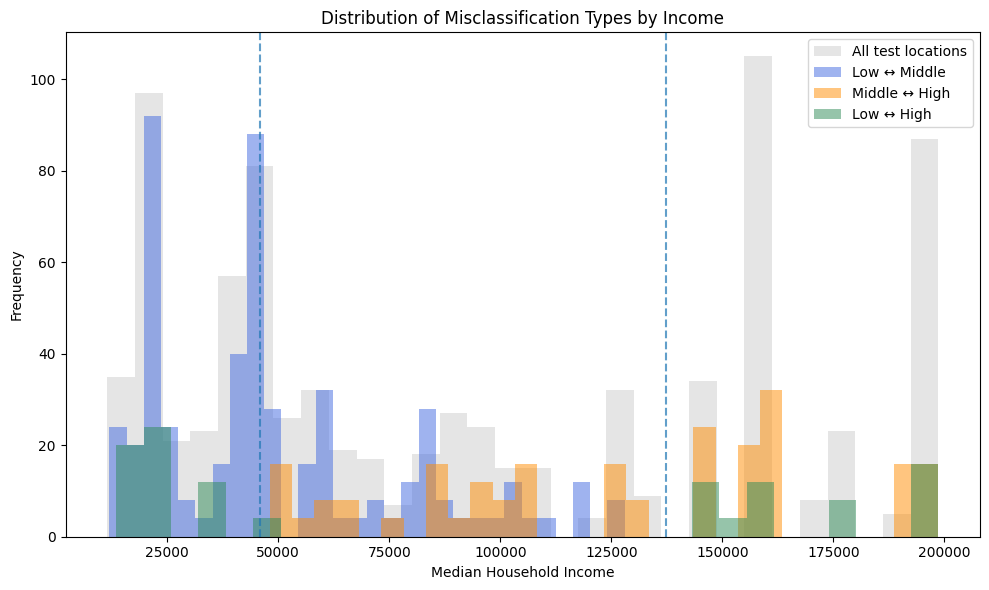

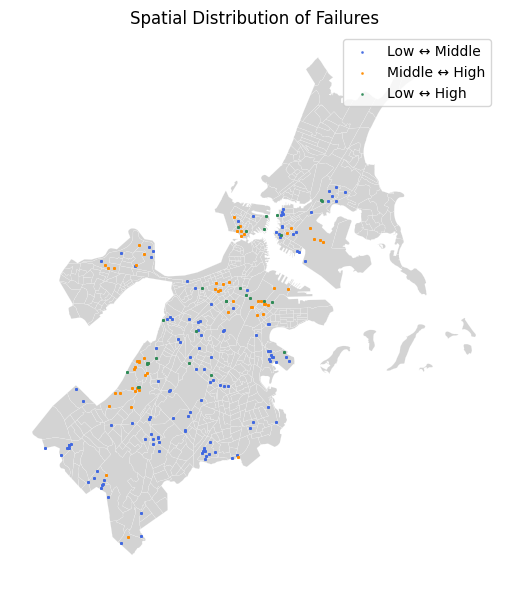

In [ ]:
# Load data
train_ds, val_ds, test_ds, test_df = dataloading(
    img_size=384,
    batch_size=16,
    preprocess_fn=tf.keras.applications.efficientnet_v2.preprocess_input,
)

# Load model + median aggregation
model, results = load_model_and_aggregate(
    model_path=f"{RESULTS_DIR}/best_efficientnetv2s.keras",
    train_ds=train_ds,
    test_ds=test_ds,
    test_df=test_df
)

# Income merge
income_MA = pd.read_csv("../Input/ACSDT5Y2019/ACSDT5Y2019.B19013-Data.csv")
income_MA = income_MA.iloc[1:]
income_MA["GEOID10"] = income_MA["GEO_ID"].str[-12:]
income_MA["median_income"] = pd.to_numeric(
    income_MA["B19013_001E"],
    errors="coerce"
)
income_MA = income_MA.dropna(subset=["median_income"])
income_MA = income_MA[["GEOID10", "median_income"]]

label_map = {0: "Low", 1: "Middle", 2: "High"}

results["actual_label"] = results["actual"].map(label_map)
results["predicted_label"] = results["predicted"].map(label_map)
results["GEOID"] = results["GEOID"].astype(str).str.zfill(12)

results = results.merge(
    income_MA,
    left_on="GEOID",
    right_on="GEOID10",
    how="left"
)

# Failure types
def failure_type(row):
    if row["actual"] == row["predicted"]:
        return None

    pair = frozenset([row["actual"], row["predicted"]])

    return {
        frozenset([0, 1]): "Low ↔ Middle",
        frozenset([1, 2]): "Middle ↔ High",
        frozenset([0, 2]): "Low ↔ High",
    }[pair]

results["failure_type"] = results.apply(failure_type, axis=1)
failures = results[results["failure_type"].notna()]

# Load Shape File
blockgp_MA = gpd.read_file("../Input/nhgis0058_shape-nhgis0058_shapefile_tl2010_250_blck_grp_2010/MA_blck_grp_2010.shp").to_crs(epsg=3857)  # Source: NHGIS
blockgp_MA = blockgp_MA[blockgp_MA['COUNTYFP10'].isin(["025"])] # Boston's County fip is "025"
boston_bg = blockgp_MA.dissolve()

# Get geometry from metadata
zip_path = "../Input/streetview_dataset.zip"
metadata = "streetview_dataset/metadata.csv"
with zipfile.ZipFile(zip_path, "r") as z:
    with z.open(metadata) as f:
        metadata = pd.read_csv(f)
metadata["geometry"] = metadata.apply(lambda row: Point(row["centroid_lng"], row["centroid_lat"]), axis=1)
metadata = gpd.GeoDataFrame(metadata, geometry="geometry", crs="EPSG:4326").to_crs(epsg=3857)
metadata["filename"] = metadata["filename"].str.rsplit("_", n=1).str[0]
metadata = metadata[["geometry", "filename"]]
failures = pd.merge(failures, metadata, left_on="loc_id", right_on="filename", how="left")
failures = failures[["geometry", "failure_type", "median_income"]]
failures = gpd.GeoDataFrame(failures, geometry="geometry", crs="EPSG:3857")

# Histogram
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    results["median_income"].dropna(),
    bins=30,
    alpha=0.2,
    color="grey",
    label="All test locations"
)

for ftype, color in [
    ("Low ↔ Middle", "royalblue"),
    ("Middle ↔ High", "darkorange"),
    ("Low ↔ High", "seagreen"),
]:
    ax.hist(
        failures.loc[
            failures["failure_type"] == ftype,
            "median_income"
        ].dropna(),
        bins=30,
        alpha=0.5,
        color=color,
        label=ftype
    )

ax.set_xlabel("Median Household Income")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Misclassification Types by Income")
ax.legend()

# Income cutoffs
ax.axvline(
    45802.0,
    linestyle="--",
    alpha=0.7,
    label="Low / Middle cutoff"
)

ax.axvline(
    137406.0,
    linestyle="--",
    alpha=0.7,
    label="Middle / High cutoff"
)

plt.tight_layout()
plt.show()


# Map
colors = {
    "Low ↔ Middle": "royalblue",
    "Middle ↔ High": "darkorange",
    "Low ↔ High": "seagreen",
}

fig, ax = plt.subplots(figsize=(10, 6))

# background
blockgp_MA.plot(
    ax=ax,
    color="lightgrey",
    edgecolor="white",
    linewidth=0.1
)

# overlay each failure type separately
for ftype, color in colors.items():

    subset = failures[failures["failure_type"] == ftype]

    if len(subset) > 0:
        subset.plot(
            ax=ax,
            color=color,
            markersize=1,
            alpha=0.8,
            label=ftype
        )
ax.set_title("Spatial Distribution of Failures")
ax.legend(loc="upper right")
ax.set_axis_off()

plt.tight_layout()
plt.show()

#### <u><strong> Generalizability</strong></u> : Does the model work on Philly?

Number of images: 1452
Here's how paths look like: GoogleStreetViewImagesPhilly/421010169024_p0_h90.jpg
Checking ID format: 421010169024 (# NA: 0)


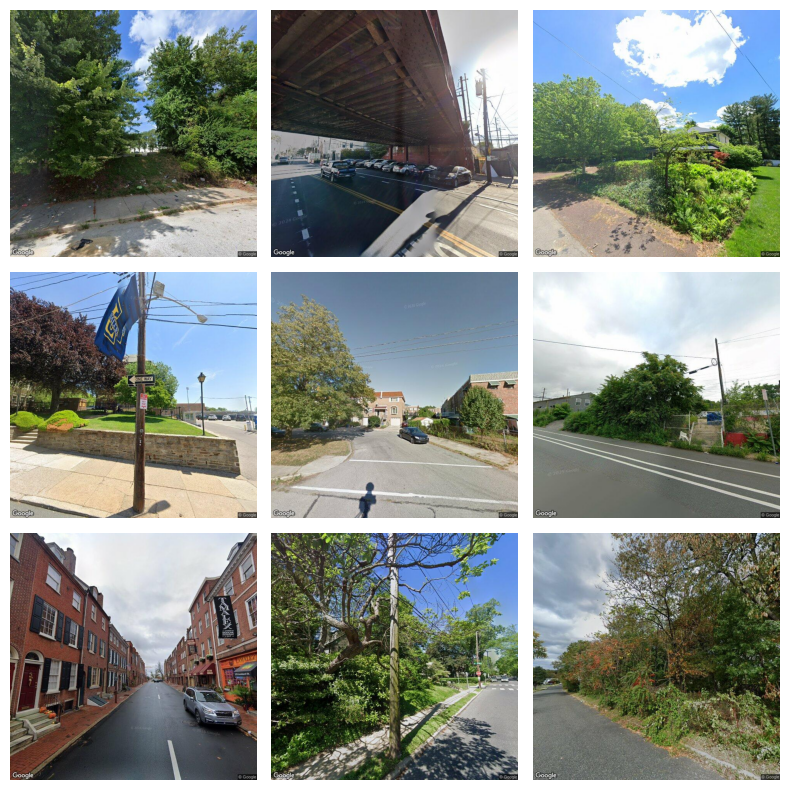

Unmatched GEOIDs: 0
income_group
0    0.344353
1    0.333333
2    0.322314
Name: proportion, dtype: float64


In [ ]:
# Build dataset

# Image file dataset
file_paths = []

# Read from zip file
with zipfile.ZipFile(PHOTO_DIR_Philly, 'r') as zip_ref:
    for file in zip_ref.namelist():
        # Skip directories and hidden files
        if not file.endswith('/') and not os.path.basename(file).startswith('.'):
            file_paths.append(file)

# Create DataFrame
images = pd.DataFrame({"file_path": file_paths})
print(f"Number of images: {len(images)}")
print(f"Here's how paths look like: {images['file_path'][0]}")

# Add neighborhood ID
images["image_name"] = images["file_path"].apply(lambda x: os.path.basename(x))
images["GEOID"] = images["image_name"].str[:12]
images = images.drop(columns=["image_name"])
print(f"Checking ID format: {images['GEOID'][0]} (# NA: {images['GEOID'].isna().sum()})")

# Printing some photos
sample_paths = images["file_path"].sample(9)
plt.figure(figsize=(8, 8))
with zipfile.ZipFile(PHOTO_DIR_Philly, 'r') as zip_ref:
    for i, path in enumerate(sample_paths):
        plt.subplot(3, 3, i + 1)
        img_data = zip_ref.read(path)
        img = Image.open(io.BytesIO(img_data))
        plt.imshow(img)
        plt.axis("off")
plt.tight_layout()
plt.show()

# Income
income_PA = pd.read_csv("../Input/ACSDT5Y2019_Philly/ACSDT5Y2019.B19013-Data.csv") # Source: https://data.census.gov/
income_PA = income_PA.iloc[1:]
income_PA["GEOID10"] = income_PA["GEO_ID"].str[-12:]
income_PA["median_income"] = pd.to_numeric(
    income_PA["B19013_001E"],
    errors="coerce"
)
income_PA = income_PA.dropna(subset=["median_income"])
income_PA = income_PA[["GEOID10", "median_income"]]

# Discretize
median_national_income = 68703
low_income_ub = (2/3) * median_national_income
high_income_lb = 2 * median_national_income
income_PA["income_group"] = pd.cut(
    income_PA["median_income"],
    bins=[-np.inf, low_income_ub, high_income_lb, np.inf],
    labels=[0, 1, 2],
    include_lowest=True
)
income_PA = income_PA.drop(columns=["median_income"])

# Merge to Images
merged = images.merge(income_PA, left_on="GEOID", right_on="GEOID10", how="left", indicator=True)
unmatched_count = (merged["_merge"] == "left_only").sum()
merged = merged.drop(columns=['GEOID10', '_merge'])
print(f"Unmatched GEOIDs: {unmatched_count}")
print(merged['income_group'].value_counts(normalize=True).sort_index())

# Save
merged.to_csv("../Output/images_bra_philly.csv", index=False)

In [ ]:
# Load data
train_ds, val_ds, test_ds, test_df = dataloading(
    csv_path="../Output/images_bra_philly.csv",
    zip_path=PHOTO_DIR_Philly,
    img_size=384,
    batch_size=16,
    preprocess_fn=tf.keras.applications.efficientnet_v2.preprocess_input,
    Philly=True
)

# Load model + median aggregation
model, results = load_model_and_aggregate(
    model_path=f"{RESULTS_DIR}/best_efficientnetv2s.keras",
    train_ds=train_ds,
    test_ds=test_ds,
    test_df=test_df
)

test: 1452 images
91/91 ━━━━━━━━━━━━━━━━━━━━ 16s 66ms/step - accuracy: 0.4408 - loss: 1.3659

Image-level sanity check: Loss: 1.3659 | Accuracy: 0.4408
Median aggregation accuracy: 0.4601
